# CEOAI:  - Baseline
## "Project KRAKEN" Implementation

### Task Summary
We are processing sensor data from a singularity (X-99). The goal is to solve three subtasks:
1.  **Geodesic Rectification**: Predict 10 spline coefficients to un-warp time.
2.  **Topological Classification**: Identify the entity class (0-49) or "Abyssal" (-1).
3.  **Heisenberg Stability**: Predict a stability scalar (0.0 to 1.0).

### Dataset
- **Slices**: (N, 3, 128, 128) - 2D holographic data.
- **Echoes**: (N, 1024, 2) - Gravitational wave time series.
- **Glyphs**: Metadata/Telemetry (CSV).
- **Targets**: Ground truth labels.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Configuration
DATA_DIR = "dataset"
SUBMISSION_FILE = "submission.csv"

# Ensure data directory exists
os.makedirs(DATA_DIR, exist_ok=True)

print("Environment setup complete.")

Environment setup complete.


In [2]:
print("Loading datasets...")

# Load Binary Files (Numpy)
X_train_slices = np.load(f"{DATA_DIR}/train_slices.npy")
X_test_slices = np.load(f"{DATA_DIR}/test_slices.npy")

X_train_echoes = np.load(f"{DATA_DIR}/train_echoes.npy")
X_test_echoes = np.load(f"{DATA_DIR}/test_echoes.npy")

# Load Tables
df_train_targets = pd.read_csv(f"{DATA_DIR}/train_targets.csv")
df_test_glyphs = pd.read_csv(f"{DATA_DIR}/test_glyphs.csv")

# Parse the Training Targets
# Subtask 1 targets need to be converted from string "0.1;0.2..." to numpy arrays
def parse_coeffs(row):
    return np.array([float(x) for x in row.split(';')])

# Apply parsing
y_train_s1 = np.stack(df_train_targets['spline_coeffs'].apply(parse_coeffs).values)
y_train_s2 = df_train_targets['class_label'].values
y_train_s3 = df_train_targets['stability_index'].values

print(f"Train Slices Shape: {X_train_slices.shape}")
print(f"Train Echoes Shape: {X_train_echoes.shape}")
print(f"Test Slices Shape: {X_test_slices.shape}")
print(f"Test Echoes Shape: {X_test_echoes.shape}")
print(f"Targets Loaded: {len(df_train_targets)}")

Loading datasets...
Train Slices Shape: (12000, 3, 128, 128)
Train Echoes Shape: (12000, 1024, 2)
Test Slices Shape: (3000, 3, 128, 128)
Test Echoes Shape: (3000, 1024, 2)
Targets Loaded: 12000


In [46]:
from sklearn.decomposition import PCA 

pca = PCA(n_components=1024*2)

X_train_slices_pca = pca.fit_transform(X_train_slices.reshape(12000, -1))
X_test_slices_pca = pca.transform(X_test_slices.reshape(3000, -1))

X_train_slices_pca.shape, X_test_slices_pca.shape

((12000, 2048), (3000, 2048))

In [47]:
pca.explained_variance_ratio_.sum()

np.float32(0.82393503)

In [48]:
X_train = np.concatenate([X_train_slices_pca.reshape(12000, -1), X_train_echoes.reshape(12000, -1), (X_train_echoes[:, 1:, 0]-X_train_echoes[:, :-1, 0]), (X_train_echoes[:, 1:, 1]-X_train_echoes[:, :-1, 1])], axis=1)
X_test = np.concatenate([X_test_slices_pca.reshape(3000, -1), X_test_echoes.reshape(3000, -1), (X_test_echoes[:, 1:, 0]-X_test_echoes[:, :-1, 0]), (X_test_echoes[:, 1:, 1]-X_test_echoes[:, :-1, 1])], axis=1)
X_train.shape, X_test.shape

((12000, 6142), (3000, 6142))

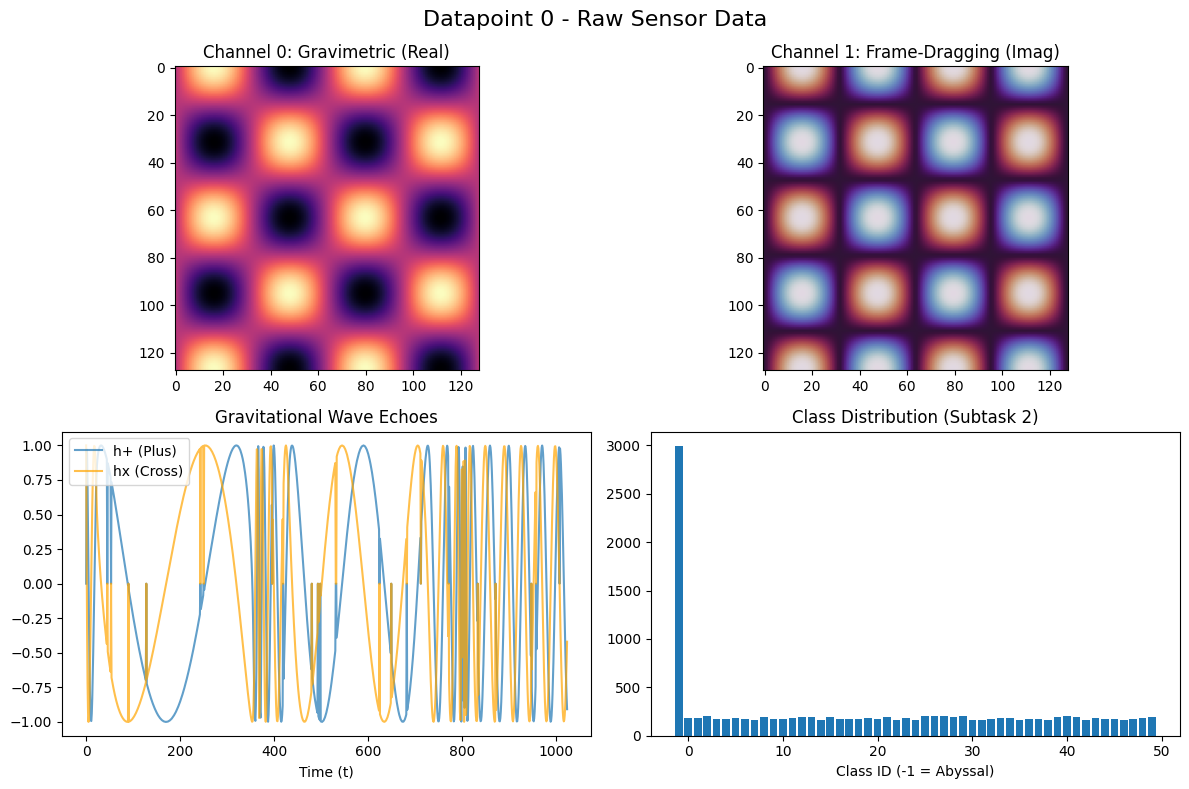

In [49]:
# Visualize a single datapoint (Index 0)
idx = 0

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(f"Datapoint {idx} - Raw Sensor Data", fontsize=16)

# 1. Visualizing Slices (The 2D Holograms)
# Channel 0: Gravimetric Potential (Real)
ax[0, 0].imshow(X_train_slices[idx, 0, :, :], cmap='magma')
ax[0, 0].set_title("Channel 0: Gravimetric (Real)")

# Channel 1: Frame-dragging (Imaginary)
ax[0, 1].imshow(X_train_slices[idx, 1, :, :], cmap='twilight')
ax[0, 1].set_title("Channel 1: Frame-Dragging (Imag)")

# 2. Visualizing Echoes (Gravitational Waves)
# Plotting the Plus (+) and Cross (x) polarization over time
time_steps = np.arange(1024)
ax[1, 0].plot(time_steps, X_train_echoes[idx, :, 0], label='h+ (Plus)', alpha=0.7)
ax[1, 0].plot(time_steps, X_train_echoes[idx, :, 1], label='hx (Cross)', alpha=0.7, color='orange')
ax[1, 0].set_title("Gravitational Wave Echoes")
ax[1, 0].legend()
ax[1, 0].set_xlabel("Time (t)")

# 3. Distribution of Classes (Target)
unique, counts = np.unique(y_train_s2, return_counts=True)
ax[1, 1].bar(unique, counts)
ax[1, 1].set_title("Class Distribution (Subtask 2)")
ax[1, 1].set_xlabel("Class ID (-1 = Abyssal)")

plt.tight_layout()
plt.show()

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [51]:
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression 
from sklearn.neural_network import MLPRegressor, MLPClassifier

In [52]:
from catboost import CatBoostRegressor 

params = {
    'iterations': 200,
    'loss_function': 'MultiRMSE',
    'random_state': 42,
    'eval_metric': 'MultiRMSE',
    'metric_period': 20,
    'max_depth': 2
}

model1 = CatBoostRegressor(**params)
model1.fit(X_train, y_train_s1[:, 1:-1])

print(f'Model1 fitted')

0:	learn: 0.3821786	total: 870ms	remaining: 2m 53s
20:	learn: 0.3613922	total: 10.9s	remaining: 1m 33s
40:	learn: 0.3489096	total: 19.9s	remaining: 1m 17s
60:	learn: 0.3392646	total: 29.1s	remaining: 1m 6s
80:	learn: 0.3302580	total: 35.4s	remaining: 52s
100:	learn: 0.3228039	total: 42.8s	remaining: 41.9s
120:	learn: 0.3156634	total: 49.3s	remaining: 32.2s
140:	learn: 0.3095431	total: 1m	remaining: 25.3s
160:	learn: 0.3041354	total: 1m 7s	remaining: 16.4s
180:	learn: 0.2986797	total: 1m 21s	remaining: 8.57s
199:	learn: 0.2939349	total: 1m 30s	remaining: 0us
Model1 fitted


In [53]:
model2 = LogisticRegression()
model2.fit(X_train, y_train_s2)

print(f'Model2 fitted')

Model2 fitted


In [56]:
from catboost import CatBoostRegressor 

params = {
    'iterations': 500,
    'loss_function': 'RMSE',
    'random_state': 42,
    'eval_metric': 'RMSE',
    'metric_period': 50,
    'max_depth': 2
}

model3 = CatBoostRegressor(**params)
model3.fit(X_train, y_train_s3)

print(f'Model3 fitted')

Learning rate set to 0.106519
0:	learn: 0.1159000	total: 111ms	remaining: 55.3s
50:	learn: 0.1142390	total: 2.52s	remaining: 22.2s
100:	learn: 0.1129760	total: 4.61s	remaining: 18.2s
150:	learn: 0.1114316	total: 6.65s	remaining: 15.4s
200:	learn: 0.1100184	total: 8.74s	remaining: 13s
250:	learn: 0.1086792	total: 10.8s	remaining: 10.7s
300:	learn: 0.1074393	total: 13.3s	remaining: 8.79s
350:	learn: 0.1062739	total: 15.6s	remaining: 6.62s
400:	learn: 0.1051902	total: 17.8s	remaining: 4.39s
450:	learn: 0.1041056	total: 20s	remaining: 2.17s
499:	learn: 0.1030566	total: 22.1s	remaining: 0us
Model3 fitted


In [57]:
# ---------------------------------------------------------------
# GENERATE SUBMISSION FILE
# ---------------------------------------------------------------

submission_rows = []

# Get list of test IDs from the glyphs file (or just generate based on N_TEST)
test_ids = df_test_glyphs['datapointID'].values

y_pred1 = np.concatenate([np.zeros((3000, 1)), model1.predict(X_test), np.ones((3000, 1))], axis=1)
y_pred2 = model2.predict(X_test)
y_pred3 = model3.predict(X_test)

print(f"Generating predictions for {len(test_ids)} test items...")

for idx, tid in enumerate(test_ids):
    # --- Subtask 1: Coefficients ---
    # Format: "f1;f2;f3..."
    # We use our calculated mean_coeffs
    s1_pred_str = ";".join([f"{x:.6f}" for x in y_pred1[idx]])
    submission_rows.append([1, tid, s1_pred_str])

    # --- Subtask 2: Class ---
    # We use our calculated mode_class
    submission_rows.append([2, tid, y_pred2[idx]])

    # --- Subtask 3: Stability ---
    # We use our calculated mean_stability
    submission_rows.append([3, tid, f"{y_pred3[idx]:.6f}"])

# Create DataFrame
df_submission = pd.DataFrame(submission_rows, columns=['subtaskID', 'datapointID', 'answer'])

# Save
df_submission.to_csv(SUBMISSION_FILE, index=False)

print("------------------------------------------------")
print(f"Submission saved to {SUBMISSION_FILE}")
print("Head of submission:")
print(df_submission.head())

Generating predictions for 3000 test items...
------------------------------------------------
Submission saved to submission.csv
Head of submission:
   subtaskID datapointID                                             answer
0          1  test_00000  0.000000;0.087150;0.240051;0.355939;0.462512;0...
1          2  test_00000                                                  1
2          3  test_00000                                           0.454968
3          1  test_00001  0.000000;0.164796;0.291497;0.415479;0.526666;0...
4          2  test_00001                                                 46
